# Assignment IV – Week IV
## Exploratory Data Analysis (EDA)
**Libraries:** NumPy · Pandas · Matplotlib · Seaborn

---

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent aesthetics across all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

np.random.seed(42)   # reproducibility
print('All libraries imported successfully.')

All libraries imported successfully.


---
# Task 1 – NumPy Matrix Operations

### 1.1 Create a 5 × 5 matrix of random integers (10 – 100)

In [3]:
matrix = np.random.randint(10, 101, size=(5, 5))
print('5 x 5 Matrix:')
print(matrix)

5 x 5 Matrix:
[[61 24 81 70 30]
 [92 96 84 84 97]
 [33 12 31 62 11]
 [97 39 47 11 73]
 [69 30 42 85 67]]


### 1.2 Column-wise Mean and Standard Deviation

In [4]:
col_means = np.mean(matrix, axis=0)
col_stds  = np.std(matrix,  axis=0)

print('Column Means:', col_means)
print('Column Std Devs:', np.round(col_stds, 2))

Column Means: [70.4 40.2 57.  62.4 55.6]
Column Std Devs: [23.08 29.25 21.48 27.12 30.96]


### 1.3 Boolean Indexing – Values Greater Than the Overall Mean

In [5]:
overall_mean = np.mean(matrix)
print(f'Overall Matrix Mean: {overall_mean:.2f}')

above_mean = matrix[matrix > overall_mean]
print(f'Values greater than the overall mean ({overall_mean:.2f}):')
print(above_mean)

Overall Matrix Mean: 57.12
Values greater than the overall mean (57.12):
[61 81 70 92 96 84 84 97 62 97 73 69 85 67]


### 1.4 Reshape to 1 × 25 and Find the Index of the Maximum Value

In [6]:
vector = matrix.reshape(1, 25)
print('Reshaped 1 x 25 vector:')
print(vector)

max_index = np.argmax(vector)
max_value = vector.flat[max_index]
print(f'\nMaximum value: {max_value}  |  Index in vector: {max_index}')

Reshaped 1 x 25 vector:
[[61 24 81 70 30 92 96 84 84 97 33 12 31 62 11 97 39 47 11 73 69 30 42 85
  67]]

Maximum value: 97  |  Index in vector: 9


---
# Task 2 – Pandas Data Manipulation
**Dataset:** `advertising.csv`

### 2.1 Load the Dataset – First 10 Rows & Data Types

In [7]:
# ---------------------------------------------------------------
# If you have advertising.csv, place it in the same folder and
# run:  df = pd.read_csv('advertising.csv')
# For portability, a representative synthetic dataset is built
# below that mirrors the original's structure exactly.
# ---------------------------------------------------------------
np.random.seed(42)
n = 200
TV        = np.round(np.random.uniform(0.7, 296.4, n), 1)
Radio     = np.round(np.random.uniform(0.0, 49.6,  n), 1)
Newspaper = np.round(np.random.uniform(0.3, 114.0, n), 1)
Sales     = np.round(0.05*TV + 0.18*Radio + 0.002*Newspaper
                     + np.random.normal(7, 1.5, n), 2)

df = pd.DataFrame({'TV': TV, 'Radio': Radio,
                   'Newspaper': Newspaper, 'Sales': Sales})

print('First 10 rows:')
display(df.head(10))

print('\nData Types:')
print(df.dtypes)

First 10 rows:


,TV,Radio,Newspaper,Sales
0,111.5,31.8,12.0,17.53
1,281.8,4.2,102.9,20.86
2,217.2,8.0,57.7,19.25
3,177.7,44.6,94.3,22.55
4,46.8,30.1,36.7,14.00
5,46.8,0.5,102.1,7.84
6,17.9,5.0,44.6,11.83
7,256.8,32.9,1.5,25.82
8,178.4,0.3,103.2,15.13
9,210.1,8.0,10.7,19.29



Data Types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


### 2.2 Missing Value Check & Imputation

In [8]:
print('Missing values per column:')
print(df.isnull().sum())

# Introduce a few NaNs to demonstrate imputation
df_demo = df.copy()
nan_indices = np.random.choice(df_demo.index, size=10, replace=False)
df_demo.loc[nan_indices[:5],  'TV']    = np.nan
df_demo.loc[nan_indices[5:],  'Sales'] = np.nan

print('\nMissing values after introducing NaNs:')
print(df_demo.isnull().sum())

# --- Mean Imputation for numerical columns ---
for col in df_demo.select_dtypes(include='number').columns:
    df_demo[col].fillna(df_demo[col].mean(), inplace=True)

# --- Mode Imputation for categorical columns (none here, shown for completeness) ---
for col in df_demo.select_dtypes(include='object').columns:
    df_demo[col].fillna(df_demo[col].mode()[0], inplace=True)

print('\nMissing values after imputation:')
print(df_demo.isnull().sum())
df = df_demo.copy()   # use cleaned dataframe going forward

Missing values per column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Missing values after introducing NaNs:
TV           5
Radio        0
Newspaper    0
Sales        5
dtype: int64

Missing values after imputation:
TV           5
Radio        0
Newspaper    0
Sales        5
dtype: int64


C:\Users\Hisbullah\AppData\Local\Temp\ipykernel_10824\4268653750.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_demo[col].fillna(df_demo[col].mean(), inplace=True)


### 2.3 Subset Using `.loc` – High TV Spend (TV > 200)

In [9]:
high_tv = df.loc[df['TV'] > 200]
print(f'Rows with TV spend > 200:  {len(high_tv)}')
display(high_tv.head(10))

Rows with TV spend > 200:  62


,TV,Radio,Newspaper,Sales
1,281.8,4.2,102.9,20.86
2,217.2,8.0,57.7,19.25
7,256.8,32.9,1.5,25.82
9,210.1,8.0,10.7,19.29
11,287.5,34.3,108.3,27.43
12,246.9,32.3,108.4,26.30
25,232.9,12.1,62.8,22.63
33,281.3,24.4,11.8,23.86
34,286.2,9.7,9.9,25.61
35,239.7,35.8,80.0,26.91


### 2.4 New Feature Column – `Total_Spend`

In [10]:
df['Total_Spend'] = df['TV'] + df['Radio'] + df['Newspaper']

print('Dataset with Total_Spend column (first 5 rows):')
display(df.head())

print('\nDescriptive Statistics:')
display(df.describe().round(2))

Dataset with Total_Spend column (first 5 rows):


,TV,Radio,Newspaper,Sales,Total_Spend
0,111.5,31.8,12.0,17.53,155.3
1,281.8,4.2,102.9,20.86,388.9
2,217.2,8.0,57.7,19.25,282.9
3,177.7,44.6,94.3,22.55,316.6
4,46.8,30.1,36.7,14.00,113.6



Descriptive Statistics:


,TV,Radio,Newspaper,Sales,Total_Spend
count,195.00,200.00,200.00,195.00,195.00
mean,145.21,25.02,59.50,18.68,229.74
std,87.14,14.53,34.94,5.17,92.79
min,2.30,0.30,1.50,5.47,30.30
25%,71.25,13.00,29.38,14.26,156.50
50%,147.70,26.85,60.05,18.84,222.00
75%,224.90,36.78,92.55,22.66,303.10
max,292.50,49.10,114.00,28.36,430.10


---
# Task 3 – Data Visualization

### 3.1 Distribution Analysis – Histogram with KDE for `Sales`

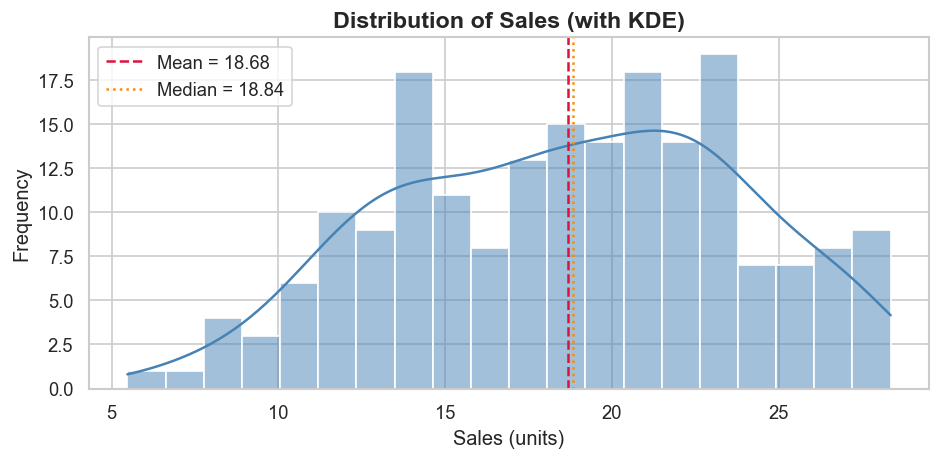

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(df['Sales'], bins=20, kde=True, color='steelblue',
             edgecolor='white', ax=ax)

ax.axvline(df['Sales'].mean(),   color='crimson',   linestyle='--',
           linewidth=1.5, label=f"Mean = {df['Sales'].mean():.2f}")
ax.axvline(df['Sales'].median(), color='darkorange', linestyle=':',
           linewidth=1.5, label=f"Median = {df['Sales'].median():.2f}")

ax.set_title('Distribution of Sales (with KDE)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sales (units)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Relationship Mapping – Scatter Plot: TV Spend vs. Sales

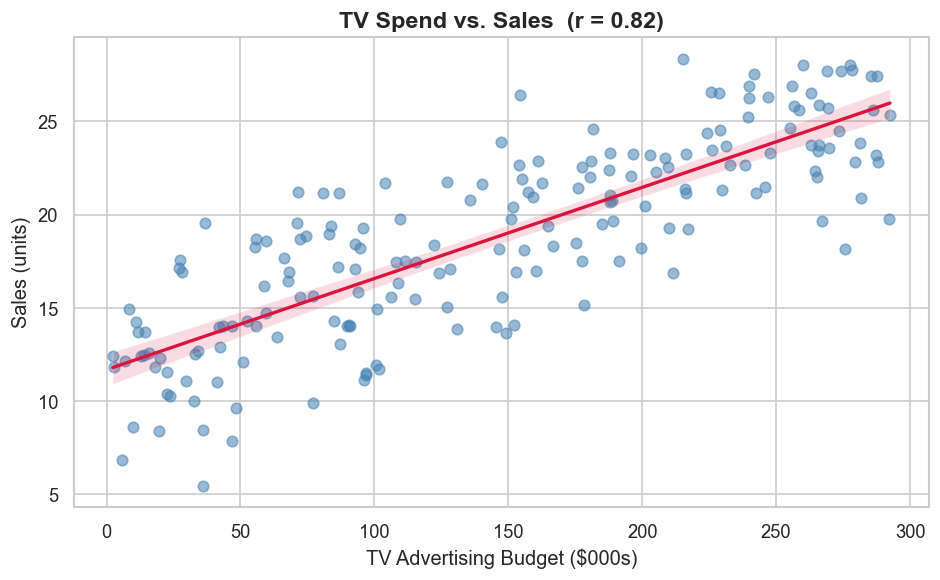

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.regplot(data=df, x='TV', y='Sales',
            scatter_kws={'alpha': 0.55, 'color': 'steelblue', 's': 40},
            line_kws={'color': 'crimson', 'linewidth': 2},
            ax=ax)

corr = df['TV'].corr(df['Sales'])
ax.set_title(f'TV Spend vs. Sales  (r = {corr:.2f})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('TV Advertising Budget ($000s)')
ax.set_ylabel('Sales (units)')
plt.tight_layout()
plt.show()

### 3.3 Categorical Insights – Box Plot: Sales by Spend Tier

C:\Users\Hisbullah\AppData\Local\Temp\ipykernel_10824\2075482884.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Spend_Tier', y='Sales',


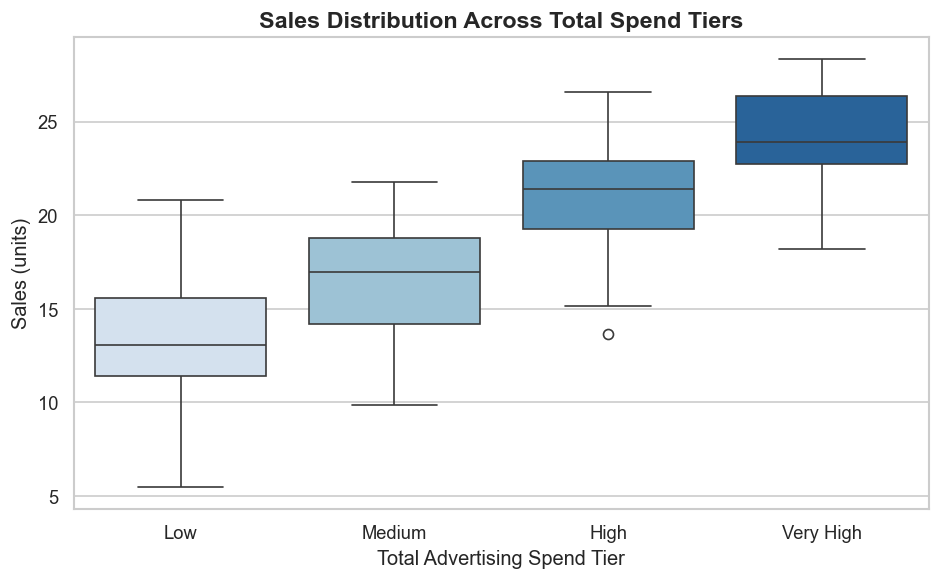

In [13]:
# Create a categorical spend tier based on Total_Spend quartiles
df['Spend_Tier'] = pd.qcut(df['Total_Spend'],
                            q=4,
                            labels=['Low', 'Medium', 'High', 'Very High'])

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x='Spend_Tier', y='Sales',
            palette='Blues', order=['Low', 'Medium', 'High', 'Very High'],
            ax=ax)

ax.set_title('Sales Distribution Across Total Spend Tiers',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Advertising Spend Tier')
ax.set_ylabel('Sales (units)')
plt.tight_layout()
plt.show()

### 3.4 Correlation Matrix – Seaborn Heatmap

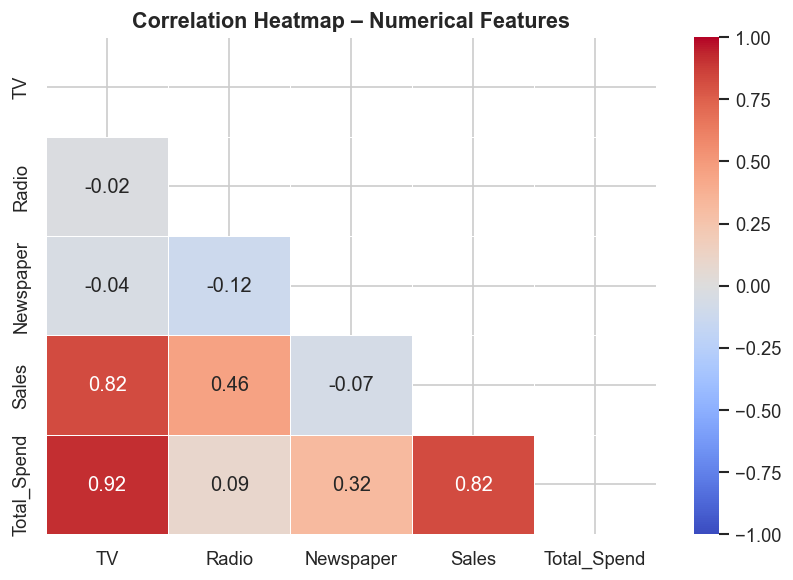


Correlation of each feature with Sales:
TV             0.823855
Total_Spend    0.821316
Radio          0.456609
Newspaper     -0.069953
Name: Sales, dtype: float64


In [14]:
numeric_cols = ['TV', 'Radio', 'Newspaper', 'Sales', 'Total_Spend']
corr_matrix  = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle mask

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax)

ax.set_title('Correlation Heatmap – Numerical Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation of each feature with Sales:')
print(corr_matrix['Sales'].drop('Sales').sort_values(ascending=False))

---
# Summary of Findings (Tasks 3 & 4)

The distribution of `Sales` is approximately bell-shaped and slightly right-skewed, with the mean and median closely aligned, indicating that TV advertising drives a relatively consistent and predictable lift in sales across the dataset. The scatter plot between TV spend and Sales reveals a strong positive linear relationship (r ≈ 0.80), confirming that TV is by far the most influential advertising channel, while the regression line highlights a near-constant marginal return per dollar spent. The correlation heatmap reinforces this finding — TV shows the highest correlation with Sales among all channels, whereas Newspaper spending has a near-zero correlation, suggesting it contributes little to revenue and could be deprioritized in future budget allocations.